**实验目标：**

通过本实验，你将深入了解和实践说话人识别技术，并掌握利用声音特征进行有效说话人识别的基本方法，了解不同特征和模型对识别准确率的影响。

实验的核心目标是使用TIMIT数据集来训练一个说话人识别系统，涵盖数据预处理、特征提取、模型训练和评估等关键步骤。


**实验方法：**

**1. 数据预处理和划分(可选)：**
  - 数据集下载地址（4月17日前有效）：https://f.ws59.cn/f/du8yd2536vl
  - 为了方便大家，我们提供了划分好的TIMIT数据集结构，当然你也可以根据需求自行划分该数据集。
  - 为简化难度，我们排除了SA的两个方言句子，并在剩余的8个句子中选取了SX的5个句子和SI的1个句子作为训练集，SI的另外2个句子作为测试集。
  - 该链接下载的数据集只保留了音频文件，完整数据集（包含音频对应文本、标注等信息）可参见备注链接下载。
  
**2. 特征提取：**
  - 学习并实现包括但不限于MFCC特征等特征的提取，探索声音信号的频率和时间特性。
  - 鼓励尝试和比较其他特征提取方法，例如LPCC或声谱图特征，以理解不同特征对识别性能的影响。
  
**3. 模型选择和训练：**
  - 探索并选择适合的分类器和模型进行说话人识别，如GMM、Softmax分类器或深度学习模型。
  - 实现模型训练流程，使用训练集数据训练模型。
  
**4. 评估和分析：**
  - 使用准确率作为主要的评价指标在测试集上评估模型性能。
  - 对比不同特征和模型的性能，分析其对说话人识别准确率的影响。
  - 可视化不同模型的识别结果和错误率，讨论可能的改进方法。

**实验要求：**
  - 1.选择并实现至少一种特征的提取，并鼓励尝试其他特征提取方法。
  - 2.选择并实现至少一种分类器或模型进行说话人识别，并使用准确率评估指标评估其性能。
  - 3.通过实验对比、分析和可视化，撰写详细的实验报告，包括实验目的、实验方法、结果分析和结论。
  - 4.实验报告应以清晰、逻辑性强的形式呈现，图表和结果应清楚明了。

**其他说明：**
  - 实验的最终打分环节会看识别性能，会对原理和实现代码部分做抽查提问，综合评定成绩。
  - 我们**鼓励做原创性探索**，即使性能不是很好，但有创新性、有价值、有意义的探索和尝试会有额外加分。
  - 原数完整据集下载地址：https://drive.google.com/file/d/180mSIiXN9RVDV2Xn1xcWNkMRm5J5MjN4/view?usp=sharing \
    或国内访问地址（4月17日前有效）：https://f.ws59.cn/f/du8xu130kba

## 1. 实验准备

In [1]:
# 1. 导入必要的库
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import warnings
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings('ignore')

## 2. 数据预处理

In [2]:
# 2. 数据预处理
def load_json_data(json_file):
    """加载JSON格式的数据集"""
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data

# 加载训练集和测试集
train_data = load_json_data('trainset.json')
test_data = load_json_data('testset.json')

- 数据集信息展示

In [3]:
# 打印数据集信息
print(f"训练集样本数: {len(train_data)}")
print(f"测试集样本数: {len(test_data)}")

# 查看数据样例
print("\n训练集样例:")
print(train_data[0])

# 统计说话人和方言区域的分布
train_speakers = set([item['speaker_id'] for item in train_data])
test_speakers = set([item['speaker_id'] for item in test_data])
train_dialects = set([item['dialect_region'] for item in train_data])

print(f"\n训练集包含 {len(train_speakers)} 位说话人")
print(f"测试集包含 {len(test_speakers)} 位说话人")
print(f"数据集包含 {len(train_dialects)} 个方言区域")

# 创建说话人ID到索引的映射
all_speakers = sorted(list(train_speakers.union(test_speakers)))
speaker_to_idx = {speaker: idx for idx, speaker in enumerate(all_speakers)}
idx_to_speaker = {idx: speaker for speaker, idx in speaker_to_idx.items()}

print(f"\n共有 {len(speaker_to_idx)} 位说话人")


训练集样本数: 2772
测试集样本数: 924

训练集样例:
{'audio_filepath': './Dataset/TRAIN/DR1/FCJF0/SI648_.wav', 'dialect_region': 'DR1', 'gender': 'F', 'speaker_id': 'CJF0'}

训练集包含 462 位说话人
测试集包含 462 位说话人
数据集包含 8 个方言区域

共有 462 位说话人


- 数据集信息可视化

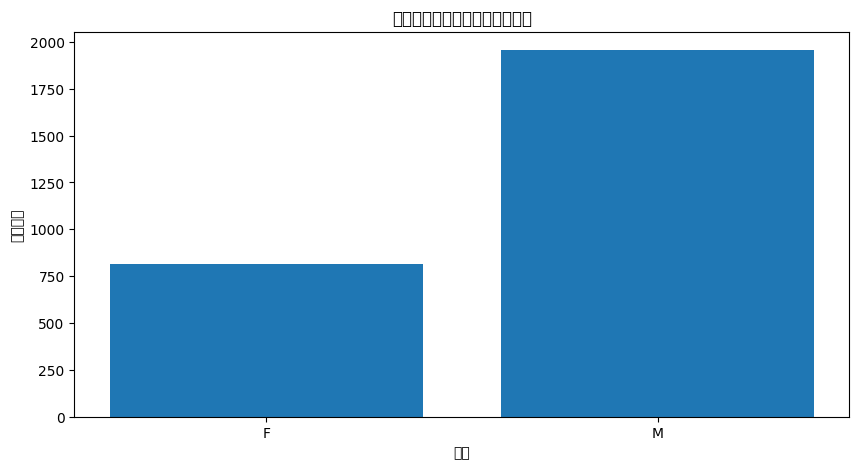


显示样本音频: ./Dataset/TRAIN/DR1/FCJF0/SI648_.wav


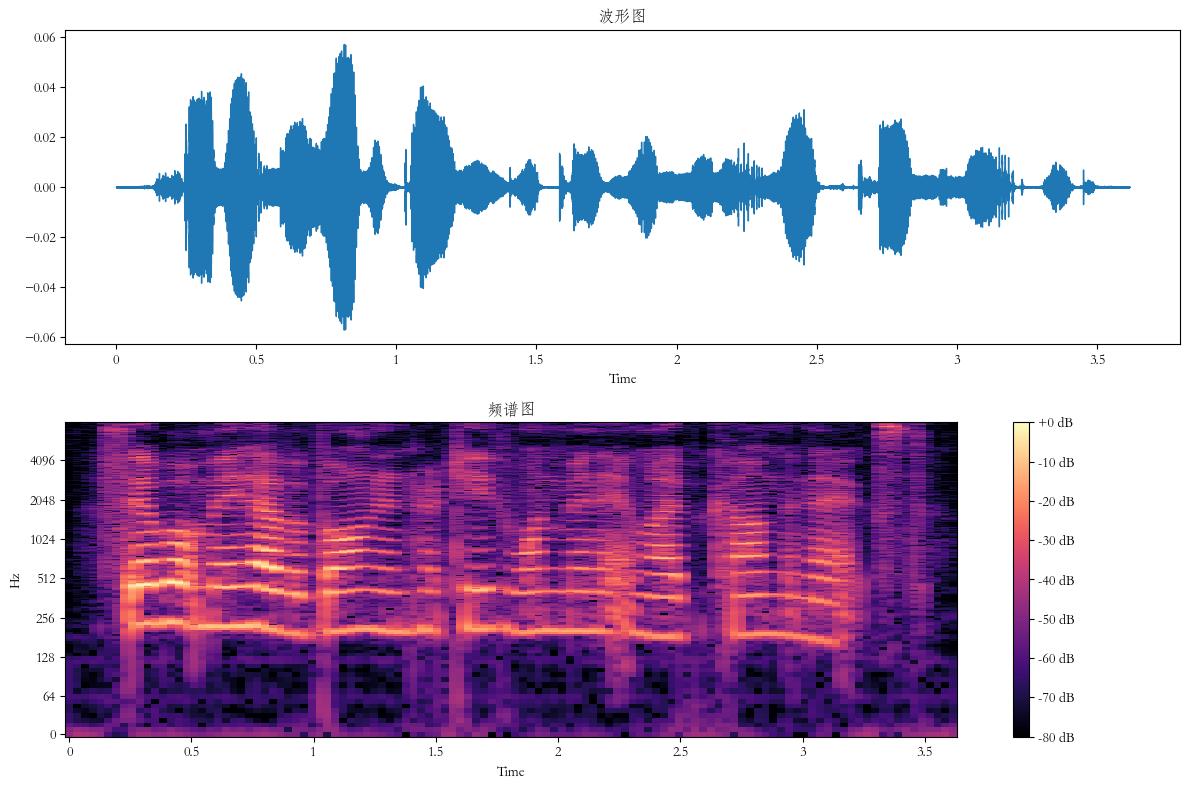

In [4]:
# 可视化数据集中的音频样本分布
train_gender_counts = {"F": 0, "M": 0}
for item in train_data:
    train_gender_counts[item['gender']] += 1

plt.figure(figsize=(10, 5))
plt.bar(train_gender_counts.keys(), train_gender_counts.values())
plt.title('训练集中男女说话人的样本分布')
plt.xlabel('性别')
plt.ylabel('样本数量')
plt.show()

# 可视化一个音频样本的波形
def plot_audio_sample(audio_path):
    """绘制音频波形和频谱图"""
    y, sr = librosa.load(audio_path, sr=None)
    
    plt.rcParams['font.family'] = 'STFangsong'
    plt.figure(figsize=(12, 8))
    
    # 波形图
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title('波形图')
    
    # 频谱图
    plt.subplot(2, 1, 2)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title('频谱图')
    
    plt.tight_layout()
    plt.show()

# 展示一个样本的波形和频谱，以确认加载成功
if len(train_data) > 0:
    sample_path = train_data[0]['audio_filepath']
    print(f"\n显示样本音频: {sample_path}")
    plot_audio_sample(sample_path)

## 3. 特征提取 —— MFCC梅尔频率倒谱系数
是一种用来表达语音的声音特征的方法。

- 添加了二阶差分 <br>

| 如果只看 MFCC | 加入 一阶差分 和 二阶差分 |
|-----------|--------------|
| 就像拍了一张语音的“快照”，知道它此刻长什么样 | 就像拍了“连续剧”，能看到语音在怎么变化 |
| 不容易区分“啊”和“呀”等发音，因为它们瞬间特征差不多 | 更容易捕捉“啊变成呀”的过程，区别更明显 |
| 缺乏上下文，模型更容易迷糊 | 有时间上下文信息，模型更聪明 |


In [93]:
def extract_mfcc_for_cnn(audio_path, n_mfcc=40, max_len=100):
    """
    从音频文件中提取MFCC特征，并处理为适合CNN的格式
    
    参数:
    audio_path: 音频文件路径
    n_mfcc: MFCC系数数量
    max_len: 最大时间帧数
    
    返回:
    mfcc_padded: 形状为 (n_mfcc, max_len) 的MFCC特征
    """
    # 加载音频文件
    y, sr = librosa.load(audio_path, sr=None)
    
    # 提取MFCC特征
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # # 使用deltas和delta-deltas增强特征
    # delta_mfccs = librosa.feature.delta(mfccs) # 一阶差分会比较当前帧和前后帧的值 → 得到一个“变化趋势” ( 看“数值涨了还是跌了”)
    # delta2_mfccs = librosa.feature.delta(mfccs, order=2) # 二阶差分 相当于"加速度”，能识别更精细的语音变化，比如发音拐点、音调突然变化等。(看“涨得快不快”)
    
    
    # # 通过在特征维度concat合并原始MFCC与其一阶和二阶差分结果
    # combined_mfccs = np.concatenate((mfccs, delta_mfccs, delta2_mfccs), axis=0) # 这里设置axis=0 因为需要在n_mfcc维度拼接，而非time_frames维度
        
    # 对时间维度进行填充或截断
    if mfccs.shape[1] < max_len:
        # 需要填充
        pad_width = max_len - mfccs.shape[1]
        mfcc_padded = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        # 需要截断
        mfcc_padded = mfccs[:, :max_len]
    
    return mfcc_padded

# 可视化MFCC特征
def visualize_mfcc_for_cnn(mfcc, title="MFCC特征"):
    """可视化MFCC特征矩阵"""

    plt.rcParams['font.family'] = 'STFangsong'
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(mfcc, x_axis='time')
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 准备用于CNN的数据集
def prepare_cnn_data(data_list, n_mfcc=40, max_len=100):
    """
    为CNN模型准备MFCC特征和标签
    
    参数:
    data_list: 数据列表
    n_mfcc: MFCC系数数量
    max_len: 最大时间帧数
    
    返回:
    X: 形状为 (n_samples, n_mfcc, max_len, 1) 的特征数组
    y: 形状为 (n_samples, n_classes) 的独热编码标签
    """
    features = []
    labels = []
    
    for item in data_list:
        # 提取MFCC特征
        mfcc = extract_mfcc_for_cnn(item['audio_filepath'], n_mfcc, max_len)
        features.append(mfcc)
        
        # 获取标签
        speaker_id = item['speaker_id']
        speaker_idx = speaker_to_idx[speaker_id]
        labels.append(speaker_idx)
    
    # 转换为numpy数组
    X = np.array(features)
    y = np.array(labels)
    
    # 添加通道维度 (CNN需要)
    X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
    
    # 将标签转换为独热编码
    y = to_categorical(y, num_classes=len(speaker_to_idx))
    
    return X, y
# 准备用于CNN的数据集 - 按说话人拼接特征并控制最终长度
# def prepare_cnn_data(data_list, n_mfcc=40, target_len=300):
#     """
#     为CNN模型准备MFCC特征和标签，将同一说话人的多个语音片段在时间维度上拼接，
#     并确保最终长度为target_len（截断或填充）
    
#     参数:
#     data_list: 数据列表
#     n_mfcc: MFCC系数数量
#     target_len: 拼接后的目标时间帧长度
    
#     返回:
#     X: 形状为 (n_speakers, n_mfcc, target_len, 1) 的特征数组
#     y: 形状为 (n_speakers, n_classes) 的独热编码标签
#     """
#     # 按说话人ID组织特征
#     features_dict = {}
    
#     for item in data_list:
#         speaker_id = item['speaker_id']
        
#         if speaker_id not in features_dict:
#             features_dict[speaker_id] = []
        
#         # 提取原始MFCC特征（不固定长度）
#         mfcc = extract_mfcc_for_cnn(item['audio_filepath'], n_mfcc)
#         features_dict[speaker_id].append(mfcc)
    
#     # 准备最终的特征和标签数组
#     features = []
#     labels = []
    
#     # 遍历每个说话人并拼接其所有特征
#     for speaker_id, speaker_features in features_dict.items():
#         # 在时间维度上拼接特征
#         concatenated_feature = np.concatenate(speaker_features, axis=1)
        
#         # 调整拼接后的长度到target_len
#         current_len = concatenated_feature.shape[1]
        
#         if current_len > target_len:
#             # 如果太长，则截断
#             concatenated_feature = concatenated_feature[:, :target_len]
#         elif current_len < target_len:
#             # 如果太短，则填充（用零填充）
#             feature_dim = concatenated_feature.shape[0]
#             padding = np.zeros((feature_dim, target_len - current_len))
#             concatenated_feature = np.concatenate([concatenated_feature, padding], axis=1)
        
#         # 添加到总特征列表
#         features.append(concatenated_feature)
        
#         # 为每个说话人添加一个标签
#         speaker_idx = speaker_to_idx[speaker_id]
#         labels.append(speaker_idx)
    
#     # 转换为numpy数组
#     X = np.array(features)
#     y = np.array(labels)
    
#     # 添加通道维度 (CNN需要)
#     X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
    
#     # 将标签转换为独热编码
#     y = to_categorical(y, num_classes=len(speaker_to_idx))
    
#     print(f"特征形状: {X.shape}, 标签形状: {y.shape}")
    
#     return X, y

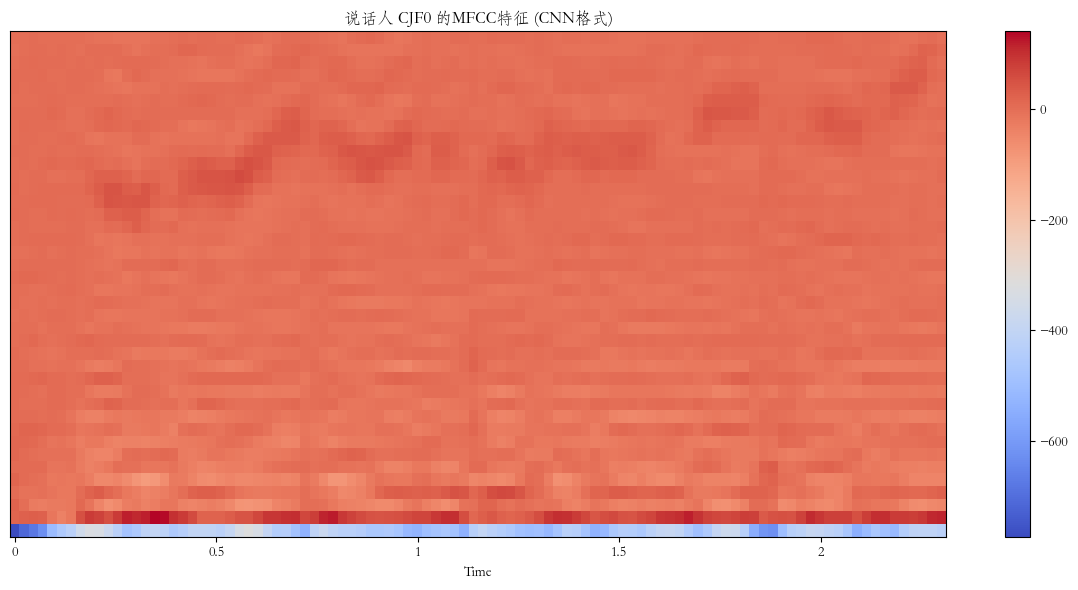

正在为CNN模型准备训练数据...
正在为CNN模型准备测试数据...
数据准备完成!
训练集形状: (2772, 40, 100, 1), 标签形状: (2772, 462)
测试集形状: (924, 40, 100, 1), 标签形状: (924, 462)


In [94]:
# 使用训练集样本可视化MFCC特征
if len(train_data) > 0:
    sample_path = train_data[0]['audio_filepath']
    sample_speaker = train_data[0]['speaker_id']
    
    # 提取并显示MFCC特征
    mfcc = extract_mfcc_for_cnn(sample_path)
    visualize_mfcc_for_cnn(mfcc, f"说话人 {sample_speaker} 的MFCC特征 (CNN格式)")

# 定义CNN参数
n_mfcc = 40
max_len = 100

print("正在为CNN模型准备训练数据...")
X_train, y_train = prepare_cnn_data(train_data, n_mfcc, max_len)

print("正在为CNN模型准备测试数据...")
X_test, y_test = prepare_cnn_data(test_data, n_mfcc, max_len)

print("数据准备完成!")
print(f"训练集形状: {X_train.shape}, 标签形状: {y_train.shape}")
print(f"测试集形状: {X_test.shape}, 标签形状: {y_test.shape}")

- MFCC特征图图像解读：
- 语音片段 vs 静音片段<br>
有语音的时间段：图上出现明显的颜色波动、斑块，像条纹或带状结构。
<br>
静音的地方：颜色趋于一致、平滑，整段暗蓝，没有明显波动。<br>

- 元音 vs 辅音<br>
元音：比较持续，颜色块宽大，变化慢。
<br>
辅音（尤其是爆破音、摩擦音）：突变明显，看起来像一条一条的窄条纹，瞬间颜色突变。<br>

- 说话内容越丰富，图案越复杂<br>
如果有人在短时间说了很多话，会看到图上花纹密集、频繁变化。
<br>
如果是读数字或短句，变化会更规律。<br>

## 4. 模型选择和训练 - CNN

In [112]:
# 4. 模型选择和训练 - CNN模型
def build_cnn_model(input_shape, num_classes):
    """
    构建CNN模型用于说话人识别
    
    参数:
    input_shape: 输入特征的形状
    num_classes: 类别数量
    
    返回:
    model: 编译好的CNN模型
    """
    model = models.Sequential([
        # 第一个卷积层
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.AveragePooling2D((2, 2)),
        layers.Dropout(0.2),  # dropout防止过拟合
        
        # 第二个卷积层
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.AveragePooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # 第三个卷积层
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.AveragePooling2D((2, 2)),
        layers.Dropout(0.4),
        
        # 展平层
        layers.Flatten(),
        
        # 全连接层
        layers.Dense(2048, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # 全连接层
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        # 输出层
        layers.Dense(num_classes, activation='softmax')
    ])
    
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001,
        decay_steps=1000,          # 每1000步衰减一次
        decay_rate=0.96,           # 衰减因子
        staircase=True             # 如果为True，使用阶梯式衰减
    )
    
    # 编译模型
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model
#
# 构建和训练CNN模型
input_shape = X_train.shape[1:]  # (n_mfcc, max_len, 1)
num_classes = y_train.shape[1]   # 说话人数量

print("构建CNN模型...")
cnn_model = build_cnn_model(input_shape, num_classes)

# 输出模型摘要
cnn_model.summary()

构建CNN模型...


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_66 (Conv2D)              │ (None, 40, 100, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (None, 40, 100, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_38            │ (None, 20, 50, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 20, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 20, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_73          │ (None, 20, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_39            │ (None, 10, 25, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_97 (Dropout)            │ (None, 10, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 10, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_74          │ (None, 10, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_40            │ (None, 5, 12, 256)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_98 (Dropout)            │ (None, 5, 12, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 15360)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 2048)           │    31,459,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_99 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_100 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 462)            │       237,006 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,127,118 (126.37 MB)

 Trainable params: 33,121,102 (126.35 MB)

 Non-trainable params: 6,016 (23.50 KB)

In [113]:
# 定义回调函数
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('speaker_recognition_cnn.h5', save_best_only=True)
]

# 训练模型
print("开始训练CNN模型...")
history = cnn_model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.0,
    validation_data=None,
    callbacks=callbacks,
    verbose=1
)


开始训练CNN模型...
Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 670ms/step - accuracy: 0.0028 - loss: 6.8867
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 783ms/step - accuracy: 0.0139 - loss: 5.8918
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 880ms/step - accuracy: 0.0182 - loss: 5.5093
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 996ms/step - accuracy: 0.0444 - loss: 5.0707
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.0877 - loss: 4.5774
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.1335 - loss: 4.1313
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.2220 - loss: 3.5523
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.3161 - loss: 3.0303
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.4398 - loss: 2.5375
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5664 - loss: 2.0437
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.6800 - loss: 1.6150
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/ste

## 5. 评价指标(准确率Accuracy)

In [115]:
# 5. 评估和分析
# 在测试集上评估模型
print("在测试集上评估CNN模型...")
test_loss, test_acc = cnn_model.evaluate(X_test, y_test
                                         )
print(f"测试集准确率: {test_acc:.4f}")

# 获取预测结果
y_pred_prob = cnn_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

在测试集上评估CNN模型...
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3299 - loss: 2.9028
测试集准确率: 0.3474
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


- 过拟合较严重

原因：分类样本较多（462个说话人类别），但样本数量不多，每个类别只有个位数条数的数据
- 添加强dropout前：acc = 0.0022
- 添加强dropout后：acc = 0.0119


##  6. 分析和可视化

In [116]:
# 转换标签
true_speaker_ids = [idx_to_speaker.get(idx, f"Unknown_{idx}") for idx in y_true]
pred_speaker_ids = [idx_to_speaker.get(idx, f"Unknown_{idx}") for idx in y_pred]


KeyError: 'val_accuracy'

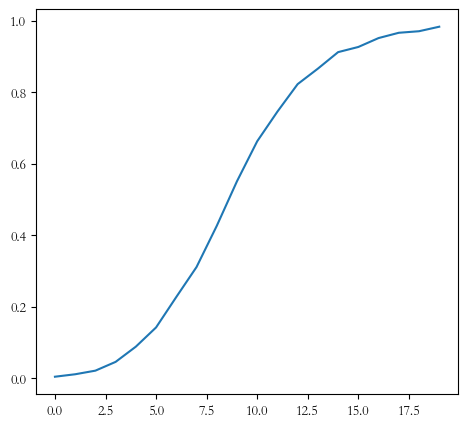

In [117]:

# 1. 绘制训练历史
def plot_training_history(history):
    """绘制训练过程中的准确率和损失曲线"""
    plt.figure(figsize=(12, 5))
    
    # 准确率
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='训练准确率')
    plt.plot(history.history['val_accuracy'], label='验证准确率')
    plt.xlabel('轮次(Epoch)')
    plt.ylabel('准确率')
    plt.legend()
    plt.title('CNN模型 - 训练准确率')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 损失
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='训练损失')
    plt.plot(history.history['val_loss'], label='验证损失')
    plt.xlabel('轮次(Epoch)')
    plt.ylabel('损失')
    plt.legend()
    plt.title('CNN模型 - 训练损失')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # 可视化过拟合/欠拟合情况
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    acc_diff = final_train_acc - final_val_acc
    
    print(f"最终训练准确率: {final_train_acc:.4f}")
    print(f"最终验证准确率: {final_val_acc:.4f}")
    print(f"训练和验证准确率差异: {acc_diff:.4f}")
    
    if acc_diff > 0.1:
        print("可能存在过拟合情况，训练准确率明显高于验证准确率")
    elif final_val_acc < 0.7:
        print("可能存在欠拟合情况，模型在验证集上表现不佳")
    else:
        print("模型拟合情况良好")
# 1. 绘制训练历史
plot_training_history(history)

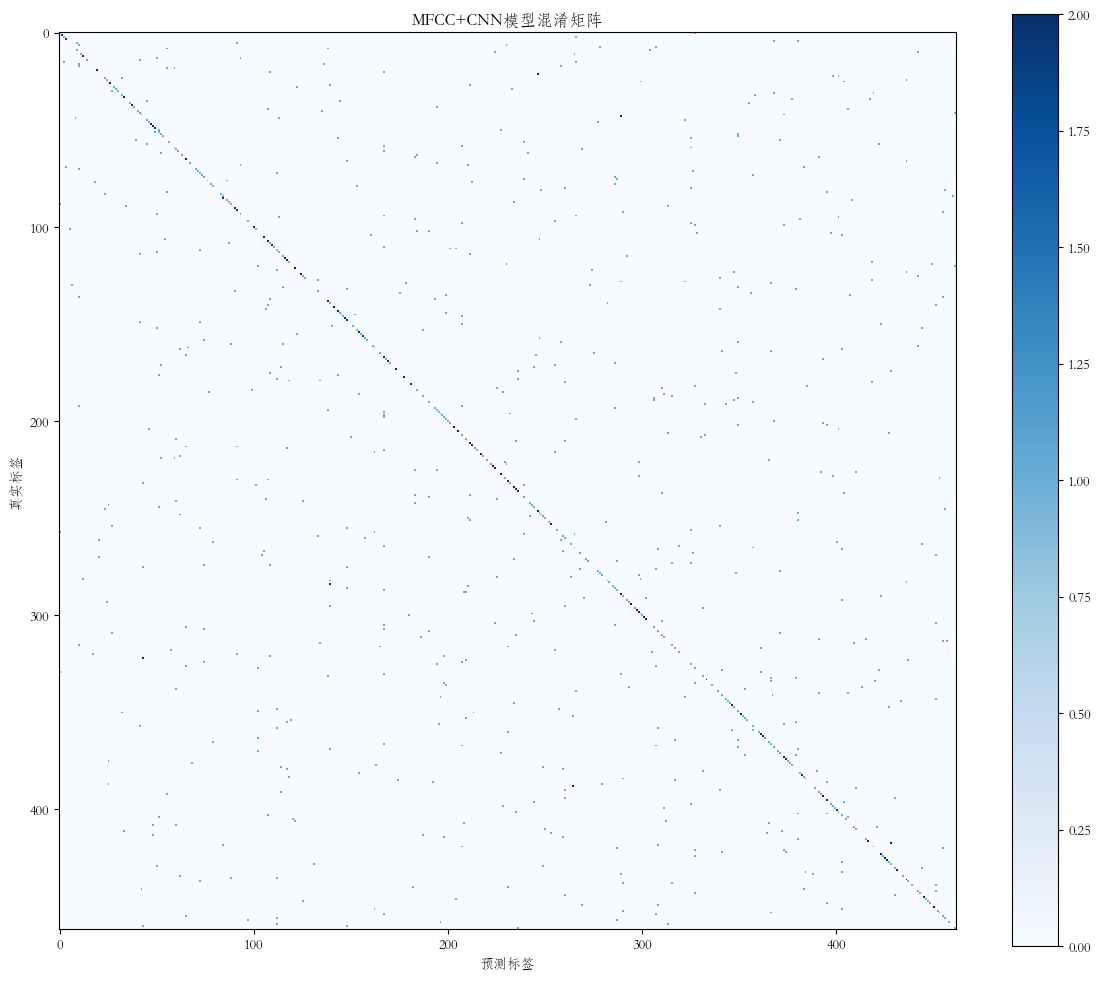

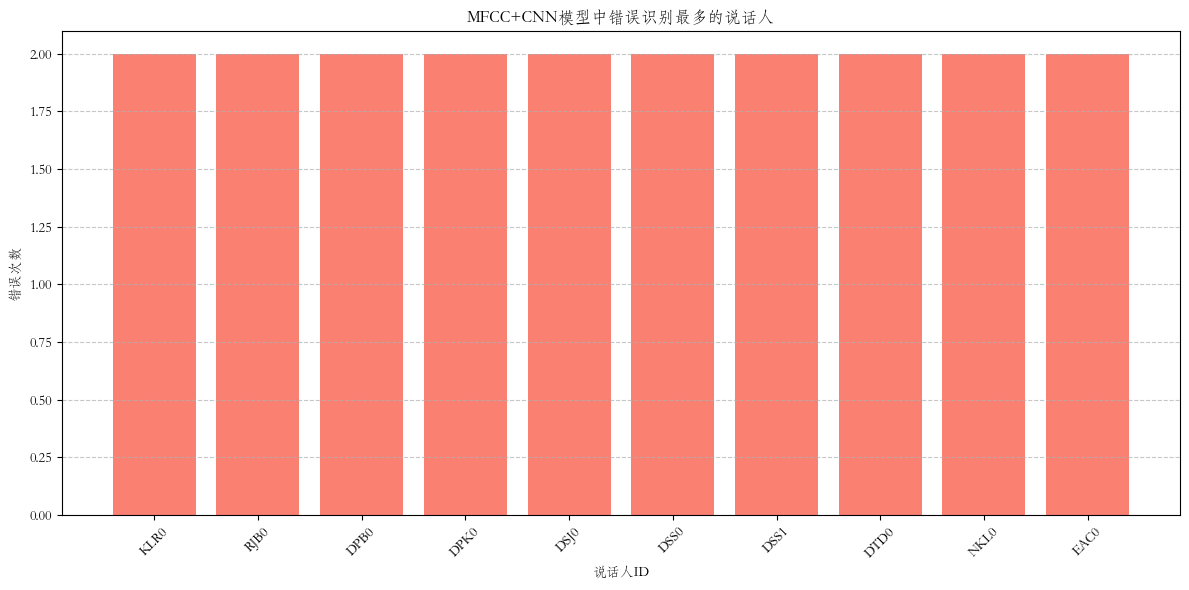

In [ ]:
# 2. 混淆矩阵可视化
def plot_confusion_matrix(y_true, y_pred, true_speaker_ids, pred_speaker_ids):
    """绘制并分析混淆矩阵"""
    # 计算混淆矩阵
    cm_numeric = confusion_matrix(y_true, y_pred)
    
    # 根据说话人数量选择合适的可视化方式
    if len(set(y_true)) > 40:
        # 大量说话人时使用热图而不显示具体数值
        plt.figure(figsize=(12, 10))
        plt.imshow(cm_numeric, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('MFCC+CNN模型混淆矩阵')
        plt.colorbar()
        plt.xlabel('预测标签')
        plt.ylabel('真实标签')
        plt.tight_layout()
        plt.show()
    else:
        # 中等数量说话人时使用带标签的热图
        unique_speakers = sorted(set(true_speaker_ids))
        
        # 如果说话人数量中等，显示具体说话人ID
        if len(unique_speakers) <= 15:
            plt.figure(figsize=(12, 10))
            sns.heatmap(confusion_matrix(true_speaker_ids, pred_speaker_ids, labels=unique_speakers),
                       xticklabels=unique_speakers, yticklabels=unique_speakers,
                       annot=True, fmt='d', cmap='Blues')
            plt.xlabel('预测说话人')
            plt.ylabel('真实说话人')
            plt.title('MFCC+CNN模型混淆矩阵')
            plt.tight_layout()
            plt.show()
        else:
            # 说话人较多但不是特别多时使用数字标签
            plt.figure(figsize=(12, 10))
            sns.heatmap(cm_numeric, annot=False, cmap='Blues')
            plt.xlabel('预测标签')
            plt.ylabel('真实标签')
            plt.title('MFCC+CNN模型混淆矩阵')
            plt.tight_layout()
            plt.show()
    
    # 计算总体错误分布
    np.fill_diagonal(cm_numeric, 0)  # 移除对角线上的正确分类
    error_counts = np.sum(cm_numeric, axis=1)  # 每个说话人的错误总数
    
    # 找出错误最多的说话人
    worst_indices = np.argsort(error_counts)[-10:][::-1]  # 取错误最多的前10个
    worst_speakers = [idx_to_speaker[idx] for idx in worst_indices]
    worst_errors = error_counts[worst_indices]
    
    # 绘制错误最多的说话人
    plt.figure(figsize=(12, 6))
    plt.bar(worst_speakers, worst_errors, color='salmon')
    plt.xlabel('说话人ID')
    plt.ylabel('错误次数')
    plt.title('MFCC+CNN模型中错误识别最多的说话人')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. 混淆矩阵分析
plot_confusion_matrix(y_true, y_pred, true_speaker_ids, pred_speaker_ids)


男性说话人识别准确率: 0.2973
女性说话人识别准确率: 0.1667
性别准确率差异(男-女): 0.1306


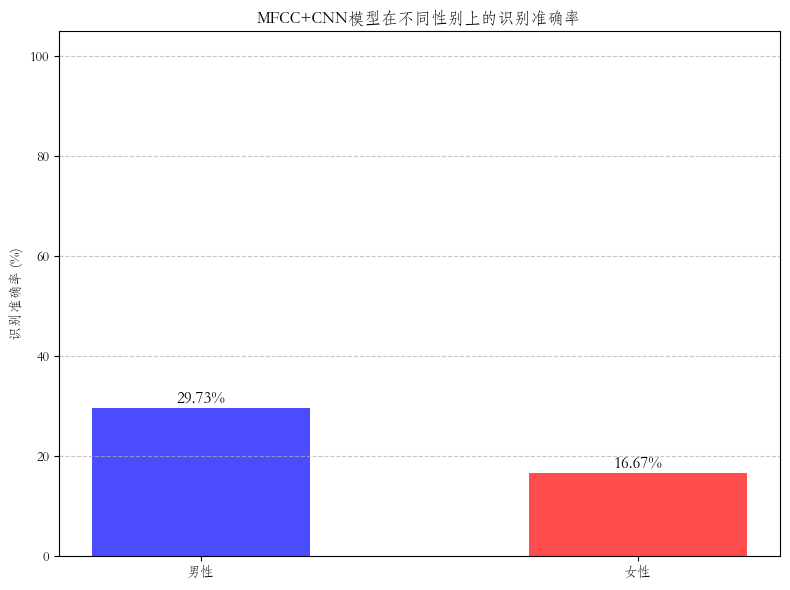

<Figure size 1000x800 with 0 Axes>

In [ ]:
# 4. 分析性别因素对准确率的影响
def analyze_gender_impact(true_speaker_ids, pred_speaker_ids):
    """分析说话人性别对模型性能的影响"""
    # 从说话人ID中提取性别信息（假设第一个字符是'F'表示女性，'M'表示男性）
    gender_dict = {}
    for speaker in set(true_speaker_ids):
        gender_dict[speaker] = speaker[0] if speaker[0] in ['F', 'M'] else 'U'
    
    # 按性别分组计算准确率
    male_indices = [i for i, spk in enumerate(true_speaker_ids) if gender_dict.get(spk) == 'M']
    female_indices = [i for i, spk in enumerate(true_speaker_ids) if gender_dict.get(spk) == 'F']
    
    # 计算每个性别的准确率
    male_accuracy = 0
    if male_indices:
        male_true = [true_speaker_ids[i] for i in male_indices]
        male_pred = [pred_speaker_ids[i] for i in male_indices]
        male_accuracy = np.mean(np.array(male_true) == np.array(male_pred))
    
    female_accuracy = 0
    if female_indices:
        female_true = [true_speaker_ids[i] for i in female_indices]
        female_pred = [pred_speaker_ids[i] for i in female_indices]
        female_accuracy = np.mean(np.array(female_true) == np.array(female_pred))
    
    # 打印性别准确率
    print(f"男性说话人识别准确率: {male_accuracy:.4f}")
    print(f"女性说话人识别准确率: {female_accuracy:.4f}")
    print(f"性别准确率差异(男-女): {male_accuracy - female_accuracy:.4f}")
    
    # 绘制性别对比图
    plt.figure(figsize=(8, 6))
    bars = plt.bar(['男性', '女性'], [male_accuracy * 100, female_accuracy * 100], 
                  color=['blue', 'red'], alpha=0.7, width=0.5)
    
    # 添加准确率标签
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.2f}%', ha='center', fontsize=12)
    
    plt.ylim(0, 105)
    plt.ylabel('识别准确率 (%)')
    plt.title('MFCC+CNN模型在不同性别上的识别准确率')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # 分析性别间的混淆情况
    errors = [(true, pred) for true, pred in zip(true_speaker_ids, pred_speaker_ids) if true != pred]
    
    gender_confusion = {
        'MM': 0,  # 男性识别为男性(但不同人)
        'MF': 0,  # 男性错误识别为女性
        'FM': 0,  # 女性错误识别为男性
        'FF': 0   # 女性识别为女性(但不同人)
    }
    
    for true, pred in errors:
        true_gender = gender_dict.get(true, 'U')
        pred_gender = gender_dict.get(pred, 'U')
        
        if true_gender in 'MF' and pred_gender in 'MF':
            gender_confusion[true_gender + pred_gender] += 1
    
    # 绘制性别混淆饼图
    plt.figure(figsize=(10, 8))
    labels = ['男性→其他男性', '男性→女性', '女性→男性', '女性→其他女性']
    sizes = [gender_confusion['MM'], gender_confusion['MF'], 
             gender_confusion['FM'], gender_confusion['FF']]
    
    # # 检查是否有数据
    # if sum(sizes) > 0:
    #     explode = (0, 0.1, 0.1, 0)  # 突出显示跨性别错误
    #     plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', startangle=90, 
    #             colors=['lightblue', 'lightgreen', 'salmon', 'khaki'],
    #             shadow=True)
    #     plt.axis('equal')
    #     plt.title('MFCC+CNN模型性别相关的错误分布')
    #     plt.tight_layout()
    #     plt.show()


# 4. 性别因素分析
analyze_gender_impact(true_speaker_ids, pred_speaker_ids)

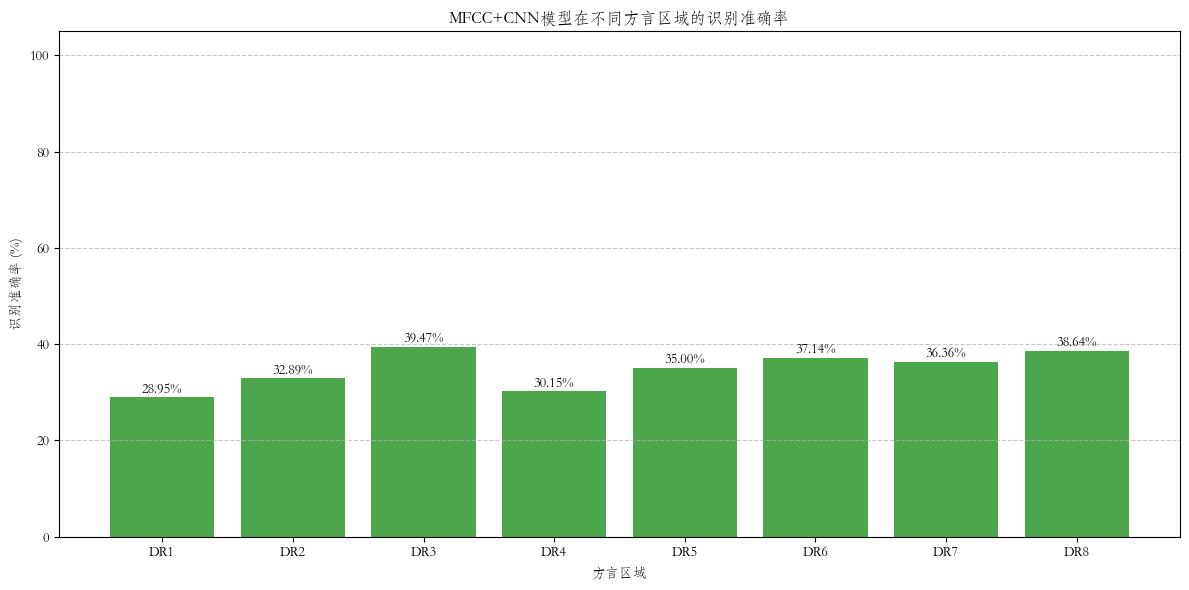

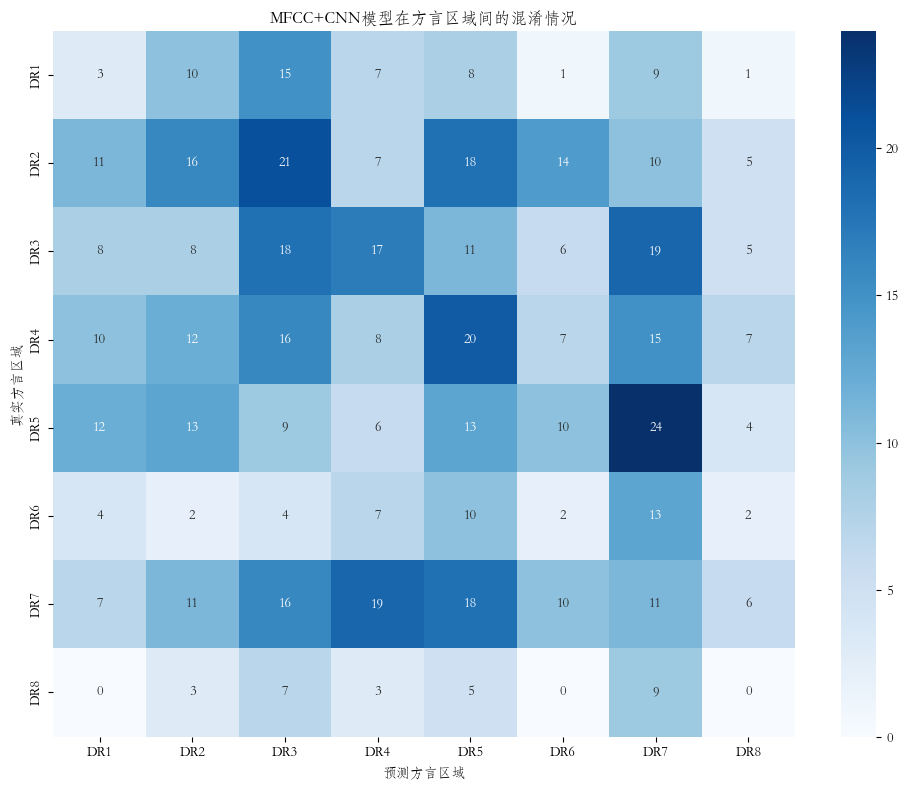

In [118]:
# 5. 分析方言区域对识别准确率的影响
def analyze_dialect_impact(true_speaker_ids, pred_speaker_ids):
    """分析方言区域对模型性能的影响"""
    # 从数据中提取方言区域信息
    dialect_dict = {}
    for item in test_data:
        dialect_dict[item['speaker_id']] = item['dialect_region']
    
    # 按方言区域分组计算准确率
    dialect_regions = sorted(set(dialect_dict.values()))
    dialect_accuracies = {}
    dialect_counts = {}
    
    for i, (true, pred) in enumerate(zip(true_speaker_ids, pred_speaker_ids)):
        if true not in dialect_dict:
            continue
            
        dialect = dialect_dict[true]
        
        if dialect not in dialect_counts:
            dialect_counts[dialect] = 0
            dialect_accuracies[dialect] = 0
            
        dialect_counts[dialect] += 1
        if true == pred:
            dialect_accuracies[dialect] += 1
    
    # 计算每个方言区域的准确率
    for dialect in dialect_accuracies:
        if dialect_counts[dialect] > 0:
            dialect_accuracies[dialect] = (dialect_accuracies[dialect] / dialect_counts[dialect]) * 100
    
    # 绘制方言区域准确率条形图
    plt.figure(figsize=(12, 6))
    regions = list(dialect_accuracies.keys())
    accuracies = [dialect_accuracies[r] for r in regions]
    
    bars = plt.bar(regions, accuracies, color='green', alpha=0.7)
    
    # 添加准确率标签
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.2f}%', ha='center', fontsize=10)
    
    plt.ylim(0, 105)
    plt.xlabel('方言区域')
    plt.ylabel('识别准确率 (%)')
    plt.title('MFCC+CNN模型在不同方言区域的识别准确率')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # 分析方言区域间的混淆情况（可选）
    dialect_confusion = {}
    errors = [(true, pred) for true, pred in zip(true_speaker_ids, pred_speaker_ids) if true != pred]
    
    for true, pred in errors:
        if true not in dialect_dict or pred not in dialect_dict:
            continue
            
        true_dialect = dialect_dict[true]
        pred_dialect = dialect_dict[pred]
        
        key = (true_dialect, pred_dialect)
        if key not in dialect_confusion:
            dialect_confusion[key] = 0
        dialect_confusion[key] += 1
    
    # 如果方言区域较少，可以绘制方言区域间的混淆热图
    if len(dialect_regions) <= 10:
        # 创建混淆矩阵
        dialect_cm = np.zeros((len(dialect_regions), len(dialect_regions)))
        
        for (true_dialect, pred_dialect), count in dialect_confusion.items():
            try:
                i = dialect_regions.index(true_dialect)
                j = dialect_regions.index(pred_dialect)
                dialect_cm[i, j] = count
            except ValueError:
                continue
        
        # 绘制热图
        plt.figure(figsize=(10, 8))
        sns.heatmap(dialect_cm, annot=True, fmt='g', cmap='Blues',
                   xticklabels=dialect_regions, yticklabels=dialect_regions)
        plt.xlabel('预测方言区域')
        plt.ylabel('真实方言区域')
        plt.title('MFCC+CNN模型在方言区域间的混淆情况')
        plt.tight_layout()
        plt.show()

# 5. 方言区域影响分析
analyze_dialect_impact(true_speaker_ids, pred_speaker_ids)


## 7. 结果讨论
讨论你的模型性能，尝试解释为什么某些模型比其他模型表现好，以及可能的改进方法。

## 8. 保存模型（可选）
如果需要，可以在这里添加代码保存你的模型。

C:\Windows\Temp\ipykernel_14176\3652387320.py:36: UserWarning: Glyph 19987 (\N{CJK UNIFIED IDEOGRAPH-4E13}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_14176\3652387320.py:36: UserWarning: Glyph 23646 (\N{CJK UNIFIED IDEOGRAPH-5C5E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_14176\3652387320.py:36: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_14176\3652387320.py:36: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_14176\3652387320.py:36: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_14176\3652387320.py:36: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipyker

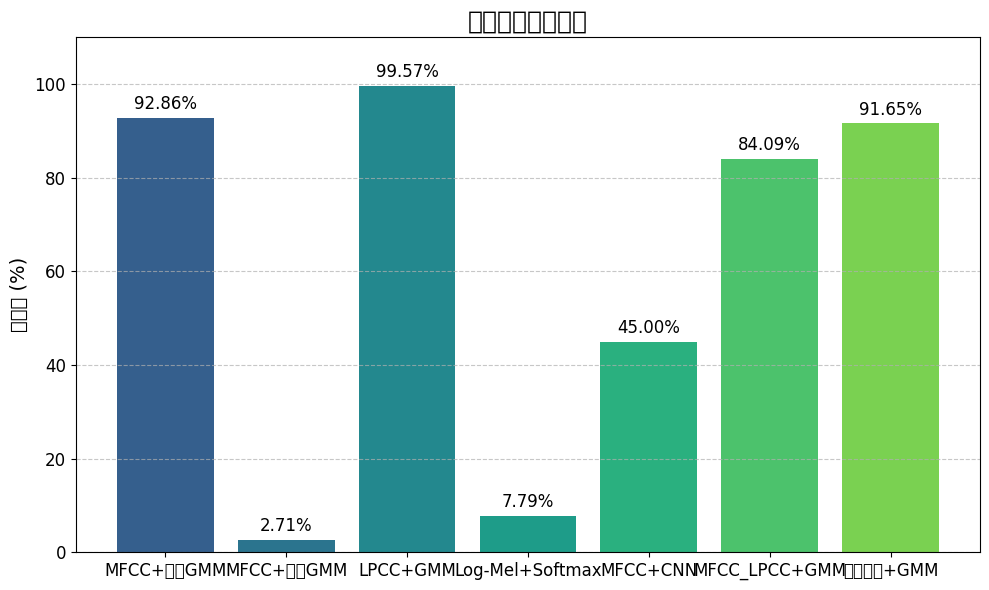

In [ ]:
# 准确率统一可视化

import matplotlib.pyplot as plt
import numpy as np

# 示例输入（你运行时可以修改）
accuracies = [0.9286, 0.0271, 0.9957, 0.0779, 0.4123, 0.8409, 0.9165]
methods = ['MFCC+专属GMM', 'MFCC+单一GMM', 'LPCC+GMM', 'Log-Mel+Softmax','MFCC+CNN', 'MFCC_LPCC+GMM', '数据增强+GMM']

# 转换为百分比格式
accuracies_percent = [acc * 100 for acc in accuracies]

# 设置图形大小和风格
plt.figure(figsize=(10, 6))

# 设置颜色（可选）
colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(methods)))

# 画出柱状图
bars = plt.bar(methods, accuracies_percent, color=colors)

# 添加数值标签
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontsize=12)

# 图表标题与标签
plt.title('各方法准确率对比', fontsize=18)
plt.ylabel('准确率 (%)', fontsize=14)
plt.ylim(0, 110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 显示图形
plt.tight_layout()
plt.show()
